# Validação de Produção (Backtesting)

### Estrutura do Notebook

1. **Setup & Carregamento:** Carregar dados novos usando estritamente as estatísticas (`mean`/`std`) do treino (Data Leakage Prevention).
2. **Motor de Inferência:** Pipeline para rodar o Modelo Robusto e os Especialistas nos mesmos dados.
3. **Painel Estatístico:** Tabelas de erro (RMSE, MAE, Bias) comparativas.
4. **Painel Visual Financeiro:**
* **Smile de Volatilidade:** Mercado vs. Modelo (O teste de fogo para opções).
* **Superfície de Preço 3D:** Para verificar suavidade e ausência de arbitragem.
* **Regime de Volatilidade (Latent Space):** O que a LSTM está "vendo"? (Comparar $\nu_t$ previsto com a Vol Realizada).
* **Erro por Moneyness/Maturidade:** Onde o modelo erra mais?


## Setup & Carregamento

### Imports e Configuração de Ambiente

In [1]:
# Bibliotecas 
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import glob
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Imports do Projeto (Garante que o Python ache os módulos)
import sys
sys.path.append(os.path.abspath('..'))

from src.config import PATHS, MODEL_CONFIG, DATA_CONFIG
from src.model import DeepHestonHybrid
from src.data_loader import _calcular_features_ativo, carregar_taxa_juros
from src.visualization import black_scholes_price

# Configuração Visual
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.figsize'] = (14, 7)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Ambiente de Validação Configurado. Device: {device}")

Ambiente de Validação Configurado. Device: cuda


### Carregador de Dados Out-of-Sample

In [2]:
# Função para carregar dados de teste

def carregar_dados_teste(ticker, ano_teste, data_stats, sequence_length=30):
    """
    Carrega dados de 2024/2025 e aplica a normalização do treino (data_stats).
    """
    print(f"--- Carregando dados de teste para {ticker} ({ano_teste}) ---")
    
    # 1. Encontrar arquivos
    path_padrao = os.path.join(PATHS['raw_data'], f"{ticker}.csv") # Ajuste se a estrutura de pastas for por ano
    # Se os arquivos estiverem separados por ano/pasta, ajuste aqui:
    # path_padrao = os.path.join(PATHS['raw_data'], '2024', f"{ticker}*.csv") 
    
    try:
        df = pd.read_csv(path_padrao, sep=';', decimal=',', skiprows=1, low_memory=False)
        df['time'] = pd.to_datetime(df['time'])
        # Filtra pelo ano desejado
        df = df[df['time'].dt.year == ano_teste].copy().sort_values('time')
    except FileNotFoundError:
        print(f"Arquivo não encontrado para {ticker}")
        return None, None

    if df.empty:
        print("Nenhum dado encontrado para o período.")
        return None, None

    # 2. Merge com Juros e Engenharia de Features
    df_juros = carregar_taxa_juros(PATHS['selic_data'])
    df['data_only'] = df['time'].dt.normalize()
    if df_juros is not None:
        df = pd.merge(df, df_juros, on='data_only', how='left')
        df['r'] = df['r'].ffill().bfill()
    else:
        df['r'] = 0.10 # Fallback
    
    # Assume q=0 se não tiver (ou carregue dividendos aqui)
    df['q'] = 0.0 

    # Calcula features (Log Ret, EWMA, etc)
    df = _calcular_features_ativo(df)
    
    # 3. Normalização (Usando data_stats do TREINO)
    # Prepara sequências LSTM
    feat_cols = ['log_ret', 'rolling_vol_20', 'ewma_vol', 'vol_parkinson', 'log_vol_fin']
    # Se tiver retorno ibov, inclua. Caso contrário, zeros.
    if 'log_ret_ibov' not in df.columns: df['log_ret_ibov'] = 0.0
    feat_cols.append('log_ret_ibov')
    
    data_vals = df[feat_cols].values.astype(np.float32)
    sequences = []
    targets = []
    phy_inputs = []
    meta_data = [] # Para guardar strike real, preço real, data para plot
    
    # ID do Ativo
    asset_id = data_stats['asset_map'].get(ticker[:4], 0)
    
    for i in range(sequence_length, len(df)):
        # LSTM Input
        seq = data_vals[i-sequence_length:i]
        sequences.append(seq)
        
        # PINN Input [S, K, T, r, q]
        row = df.iloc[i]
        S = row['spot_price']
        K = row['strike']
        T = row['days_to_maturity'] / 365.25
        r = row['r']
        q = row['q']
        
        # Normalização Z-Score (Estrita do Treino)
        S_norm = (S - data_stats['S_mean']) / data_stats['S_std']
        K_norm = (K - data_stats['K_mean']) / data_stats['K_std']
        T_norm = (T - data_stats['T_mean']) / data_stats['T_std']
        
        phy_inputs.append([S_norm, K_norm, T_norm, r, q]) # r e q geralmente não normalizamos ou normalizamos leve
        
        # Target (Preço / Strike) -> Mas vamos guardar o preço real para validação em R$
        targets.append(row['premium'] / K) 
        
        meta_data.append({
            'time': row['time'], 
            'strike': K, 
            'spot': S, 
            'premium_real': row['premium'],
            'moneyness': S/K,
            'maturity': T
        })

    # Tensores
    X_seq = torch.tensor(np.array(sequences), dtype=torch.float32)
    X_phy = torch.tensor(np.array(phy_inputs), dtype=torch.float32)
    y = torch.tensor(np.array(targets), dtype=torch.float32).unsqueeze(-1)
    ids = torch.full((len(y),), asset_id, dtype=torch.long)
    
    dataset = TensorDataset(X_seq, X_phy, y, ids)
    return dataset, pd.DataFrame(meta_data)

### Carregar Modelos (Robusto e Especialista)

In [3]:
# Carregar Stats do Treino

stats_path = os.path.join(PATHS['model_save_dir'], 'data_stats.json')
with open(stats_path, 'r') as f:
    data_stats = json.load(f)

config_adaptado = MODEL_CONFIG.copy()
config_adaptado['num_assets'] = len(data_stats['asset_map']) 

# 1. Modelo Robusto (Generalista)
model_robust = DeepHestonHybrid(config_adaptado, data_stats).to(device)
path_robust = os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth')
model_robust.load_state_dict(torch.load(path_robust, map_location=device))
model_robust.eval()
print("Modelo Robusto carregado.")

# Função Helper para carregar Especialista
def carregar_especialista(ticker):
    ticker_raiz = ticker[:4]
    path_spec = os.path.join(PATHS['model_save_dir'], f'best_{ticker_raiz}.pt')
    if not os.path.exists(path_spec):
        print(f"Especialista para {ticker_raiz} não encontrado. Usando Robusto.")
        return model_robust
    
    model_spec = DeepHestonHybrid(config_adaptado, data_stats).to(device)
    model_spec.load_state_dict(torch.load(path_spec, map_location=device))
    model_spec.eval()
    return model_spec

Modelo Robusto carregado.


## Motor de Inferência

### Análise Comparativa (Backtest)

In [4]:
# Função de Backtest

def rodar_backtest(ticker, ano=2024):
    ds, df_meta = carregar_dados_teste(ticker, ano, data_stats)
    if ds is None: return
    
    loader = DataLoader(ds, batch_size=2048, shuffle=False)
    model_spec = carregar_especialista(ticker)
    
    preds_rob = []
    preds_spec = []
    vols_spec = []
    
    with torch.no_grad():
        for x_seq, x_phy, y, ids in loader:
            x_seq, x_phy, ids = x_seq.to(device), x_phy.to(device), ids.to(device)
            
            # Inferência Robusto
            out_rob = model_robust(x_seq, x_phy, ids)
            
            # Inferência Especialista
            out_spec = model_spec(x_seq, x_phy, ids)
            
            # Desnormalização para Preço Real (R$)
            # P_real = P_norm * Strike_real
            # Recuperamos K dos inputs físicos desnormalizando
            K_norm = x_phy[:, 1:2].cpu()
            K_real = K_norm * data_stats['K_std'] + data_stats['K_mean']
            
            p_rob = out_rob['price'].cpu() * K_real
            p_spec = out_spec['price'].cpu() * K_real
            
            preds_rob.extend(p_rob.numpy().flatten())
            preds_spec.extend(p_spec.numpy().flatten())
            
            # Captura Volatilidade Latente (nu) do Especialista
            nu = out_spec['heston_params'][0].cpu()
            vols_spec.extend(torch.sqrt(nu).numpy().flatten())

    # Consolida DataFrame
    df_res = df_meta.copy()
    df_res['Pred_Robusto'] = preds_rob
    df_res['Pred_Spec'] = preds_spec
    df_res['Latent_Vol'] = vols_spec
    df_res['Erro_Robusto'] = df_res['Pred_Robusto'] - df_res['premium_real']
    df_res['Erro_Spec'] = df_res['Pred_Spec'] - df_res['premium_real']
    
    return df_res

# Execução Exemplo
df_petr = rodar_backtest('PETR4', 2024)
df_vale = rodar_backtest('VALE3', 2024)
df_abev = rodar_backtest('ABEV3', 2024)
df_csn = rodar_backtest('CSN3', 2024)
df_itau = rodar_backtest('ITUB4', 2024)

--- Carregando dados de teste para PETR4 (2024) ---
--- Carregando dados de teste para VALE3 (2024) ---
--- Carregando dados de teste para ABEV3 (2024) ---
--- Carregando dados de teste para CSN3 (2024) ---
Arquivo não encontrado para CSN3
--- Carregando dados de teste para ITUB4 (2024) ---


## Painel Estatístico

### Análise Estatístico dos modelos

In [5]:
#

def print_metrics(df, nome_ativo):
    if df is None: return
    print(f"\n=== Resultados 2024: {nome_ativo} ===")
    
    for modelo in ['Robusto', 'Spec']:
        col_erro = f'Erro_{modelo}'
        mae = np.mean(np.abs(df[col_erro]))
        rmse = np.sqrt(np.mean(df[col_erro]**2))
        bias = np.mean(df[col_erro])
        
        print(f"Model {modelo}: MAE={mae:.4f} | RMSE={rmse:.4f} | Bias={bias:.4f}")

print_metrics(df_petr, "PETR4")
print_metrics(df_vale, "VALE3")
print_metrics(df_abev, "ABEV3")
print_metrics(df_csn, "CSN3")
print_metrics(df_itau, "ITUB4")


=== Resultados 2024: PETR4 ===
Model Robusto: MAE=2.5779 | RMSE=4.9293 | Bias=1.0879
Model Spec: MAE=2.5855 | RMSE=4.9475 | Bias=1.1119

=== Resultados 2024: VALE3 ===
Model Robusto: MAE=5.0348 | RMSE=12.1656 | Bias=-0.0383
Model Spec: MAE=4.8639 | RMSE=12.0810 | Bias=-0.4797

=== Resultados 2024: ABEV3 ===
Model Robusto: MAE=0.7898 | RMSE=1.5726 | Bias=-0.3154
Model Spec: MAE=0.7922 | RMSE=1.5659 | Bias=-0.3298

=== Resultados 2024: ITUB4 ===
Model Robusto: MAE=1.3729 | RMSE=2.4096 | Bias=0.8553
Model Spec: MAE=1.2522 | RMSE=2.3122 | Bias=0.5773


## Painel Visual Financeiro

### Visualização 1 - Série Temporal e Volatilidade Latente

In [6]:
def plot_split_time_series(df, titulo):
    """
    Gera um painel de 4 gráficos verticais para análise limpa:
    1. Mercado vs Generalista
    2. Mercado vs Especialista
    3. Erro (Spread)
    4. Volatilidade Latente
    """
    # 1. Filtro Inteligente: Focar em opções ATM (0.95-1.05) para limpar o ruído visual
    mask_atm = (df['moneyness'] >= 0.95) & (df['moneyness'] <= 1.05)
    
    # Fallback se houver poucos dados
    if mask_atm.sum() < 20:
        print(f"Aviso: Poucos dados ATM para {titulo}. Usando amostra geral.")
        df_plot = df.iloc[::5].copy()
    else:
        df_plot = df[mask_atm].copy()
        
    df_plot = df_plot.sort_values('time')

    # Configuração do Grid (4 linhas verticais)
    fig, (ax_gen, ax_spec, ax_err, ax_vol) = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
    plt.subplots_adjust(hspace=0.15) # Espaço pequeno entre plots

    # --- PLOT 1: Generalista (Baseline) ---
    ax_gen.scatter(df_plot['time'], df_plot['premium_real'], 
                   color='black', s=15, alpha=0.3, label='Mercado (Real)')
    
    ax_gen.plot(df_plot['time'], df_plot['Pred_Robusto'], 
                color='tab:blue', linestyle='-', linewidth=1.5, label='Modelo Generalista')
    
    ax_gen.set_ylabel('Preço (R$)')
    ax_gen.set_title(f'{titulo}: Baseline (Generalista vs Mercado)', fontsize=12, fontweight='bold', loc='left')
    ax_gen.legend(loc='upper left')
    ax_gen.grid(True, alpha=0.2)

    # --- PLOT 2: Especialista (Fine-Tuned) ---
    ax_spec.scatter(df_plot['time'], df_plot['premium_real'], 
                    color='black', s=15, alpha=0.3, label='Mercado (Real)')
    
    ax_spec.plot(df_plot['time'], df_plot['Pred_Spec'], 
                 color='tab:green', linestyle='-', linewidth=1.5, label='Modelo Especialista')
    
    ax_spec.set_ylabel('Preço (R$)')
    ax_spec.set_title(f'{titulo}: Refinado (Especialista vs Mercado)', fontsize=12, fontweight='bold', loc='left')
    ax_spec.legend(loc='upper left')
    ax_spec.grid(True, alpha=0.2)

    # --- PLOT 3: Spread do Especialista (Erro Residual) ---
    erro = df_plot['Erro_Spec']
    ax_err.bar(df_plot['time'], erro, color=np.where(erro > 0, 'tab:red', 'tab:blue'), alpha=0.6, width=1.0)
    ax_err.axhline(0, color='black', linewidth=0.8)
    
    # Estatísticas no gráfico
    mae_val = np.mean(np.abs(erro))
    bias_val = np.mean(erro)
    ax_err.text(0.01, 0.9, f'MAE: R$ {mae_val:.2f} | Bias: R$ {bias_val:.2f}', 
                transform=ax_err.transAxes, bbox=dict(facecolor='white', alpha=0.7))
    
    ax_err.set_ylabel('Erro (R$)')
    ax_err.set_title('Spread Final (Modelo Especialista - Mercado)', fontsize=12, fontweight='bold', loc='left')
    ax_err.grid(True, alpha=0.2)

    # --- PLOT 4: Regime de Volatilidade ---
    ax_vol.plot(df_plot['time'], df_plot['Latent_Vol'], 
                color='purple', linewidth=1.5, label=r'Heston Vol ($\sqrt{\nu_t}$)')
    
    # Se tiver vol histórica para comparar
    if 'vol_parkinson' in df_plot.columns:
        ax_vol.plot(df_plot['time'], df_plot['vol_parkinson'], 
                    color='orange', linestyle=':', alpha=0.5, label='Vol. Parkinson (Histórica)')

    ax_vol.set_ylabel('Volatilidade ($\sigma$)')
    ax_vol.set_xlabel('Data')
    ax_vol.set_title('Dinâmica da Volatilidade Latente', fontsize=12, fontweight='bold', loc='left')
    ax_vol.legend(loc='upper left')
    ax_vol.grid(True, alpha=0.2)
    
    # Formatação de Datas
    plt.xticks(rotation=0)
    
    plt.show()



<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_30040\1291716446.py:73: SyntaxWarning: invalid escape sequence '\s'
  ax_vol.set_ylabel('Volatilidade ($\sigma$)')


PETR4 - Petrobrás

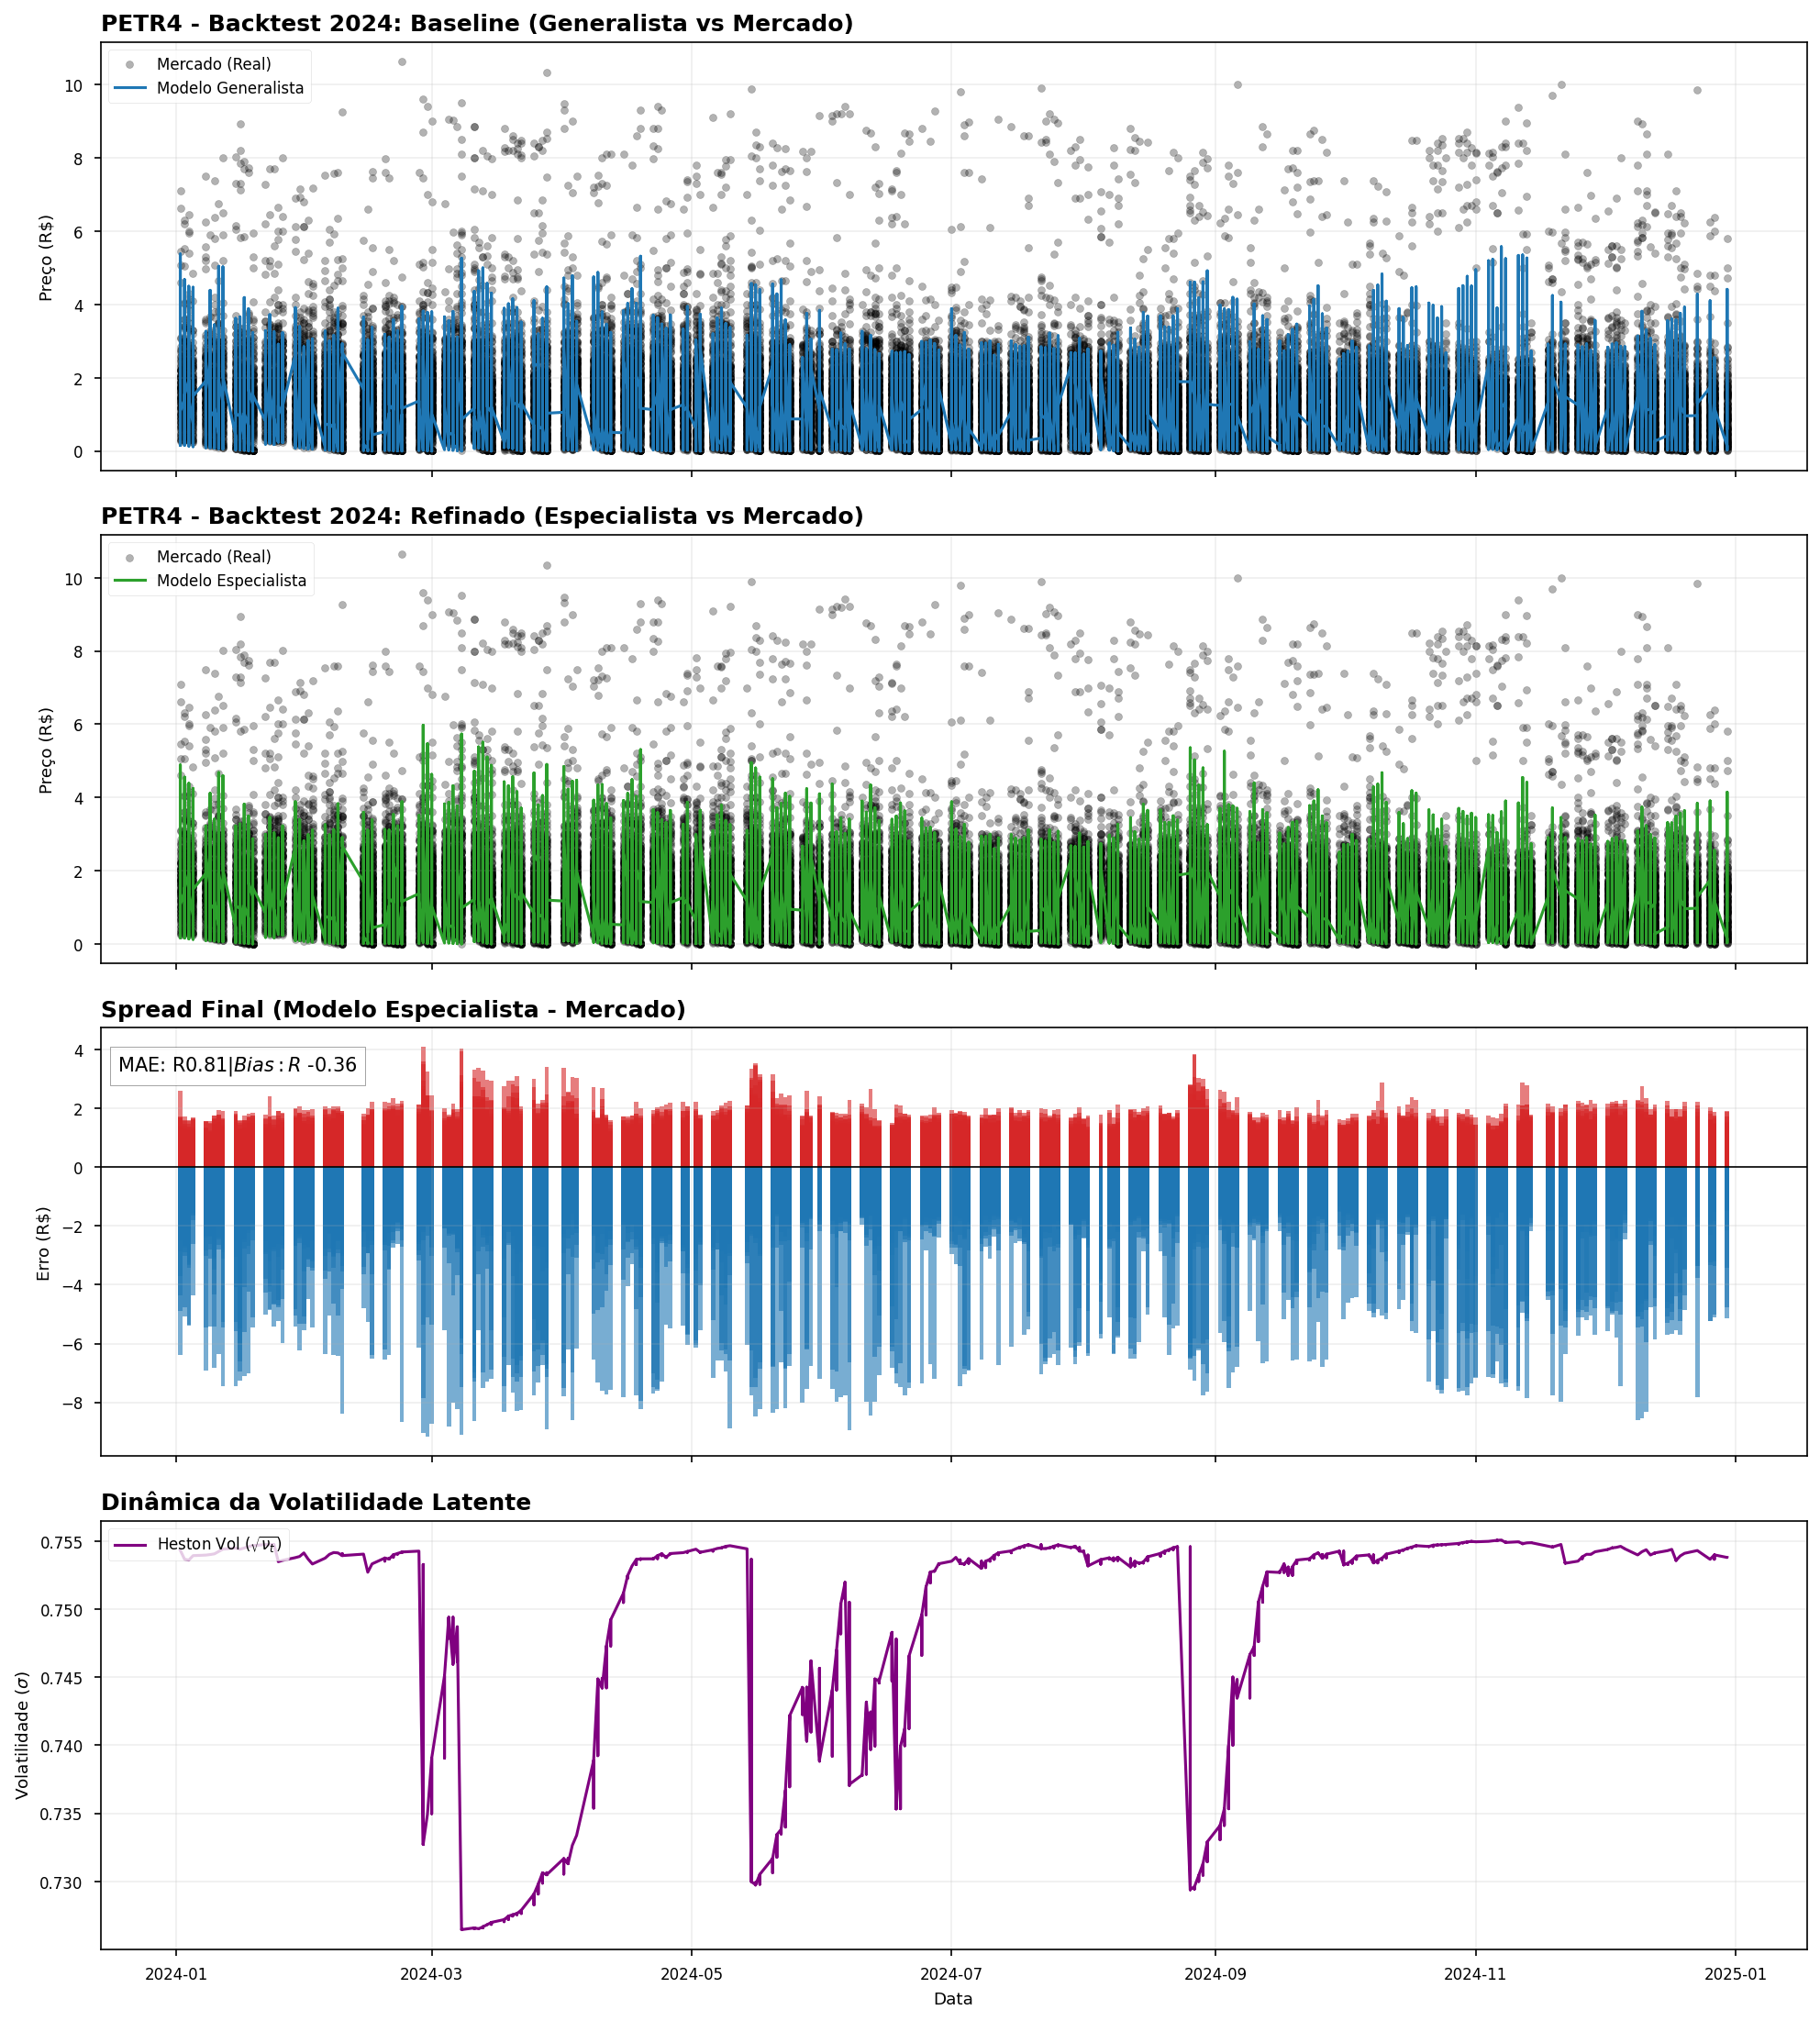

In [7]:
# Execução
plot_split_time_series(df_petr, "PETR4 - Backtest 2024")

VALE3 - Vale

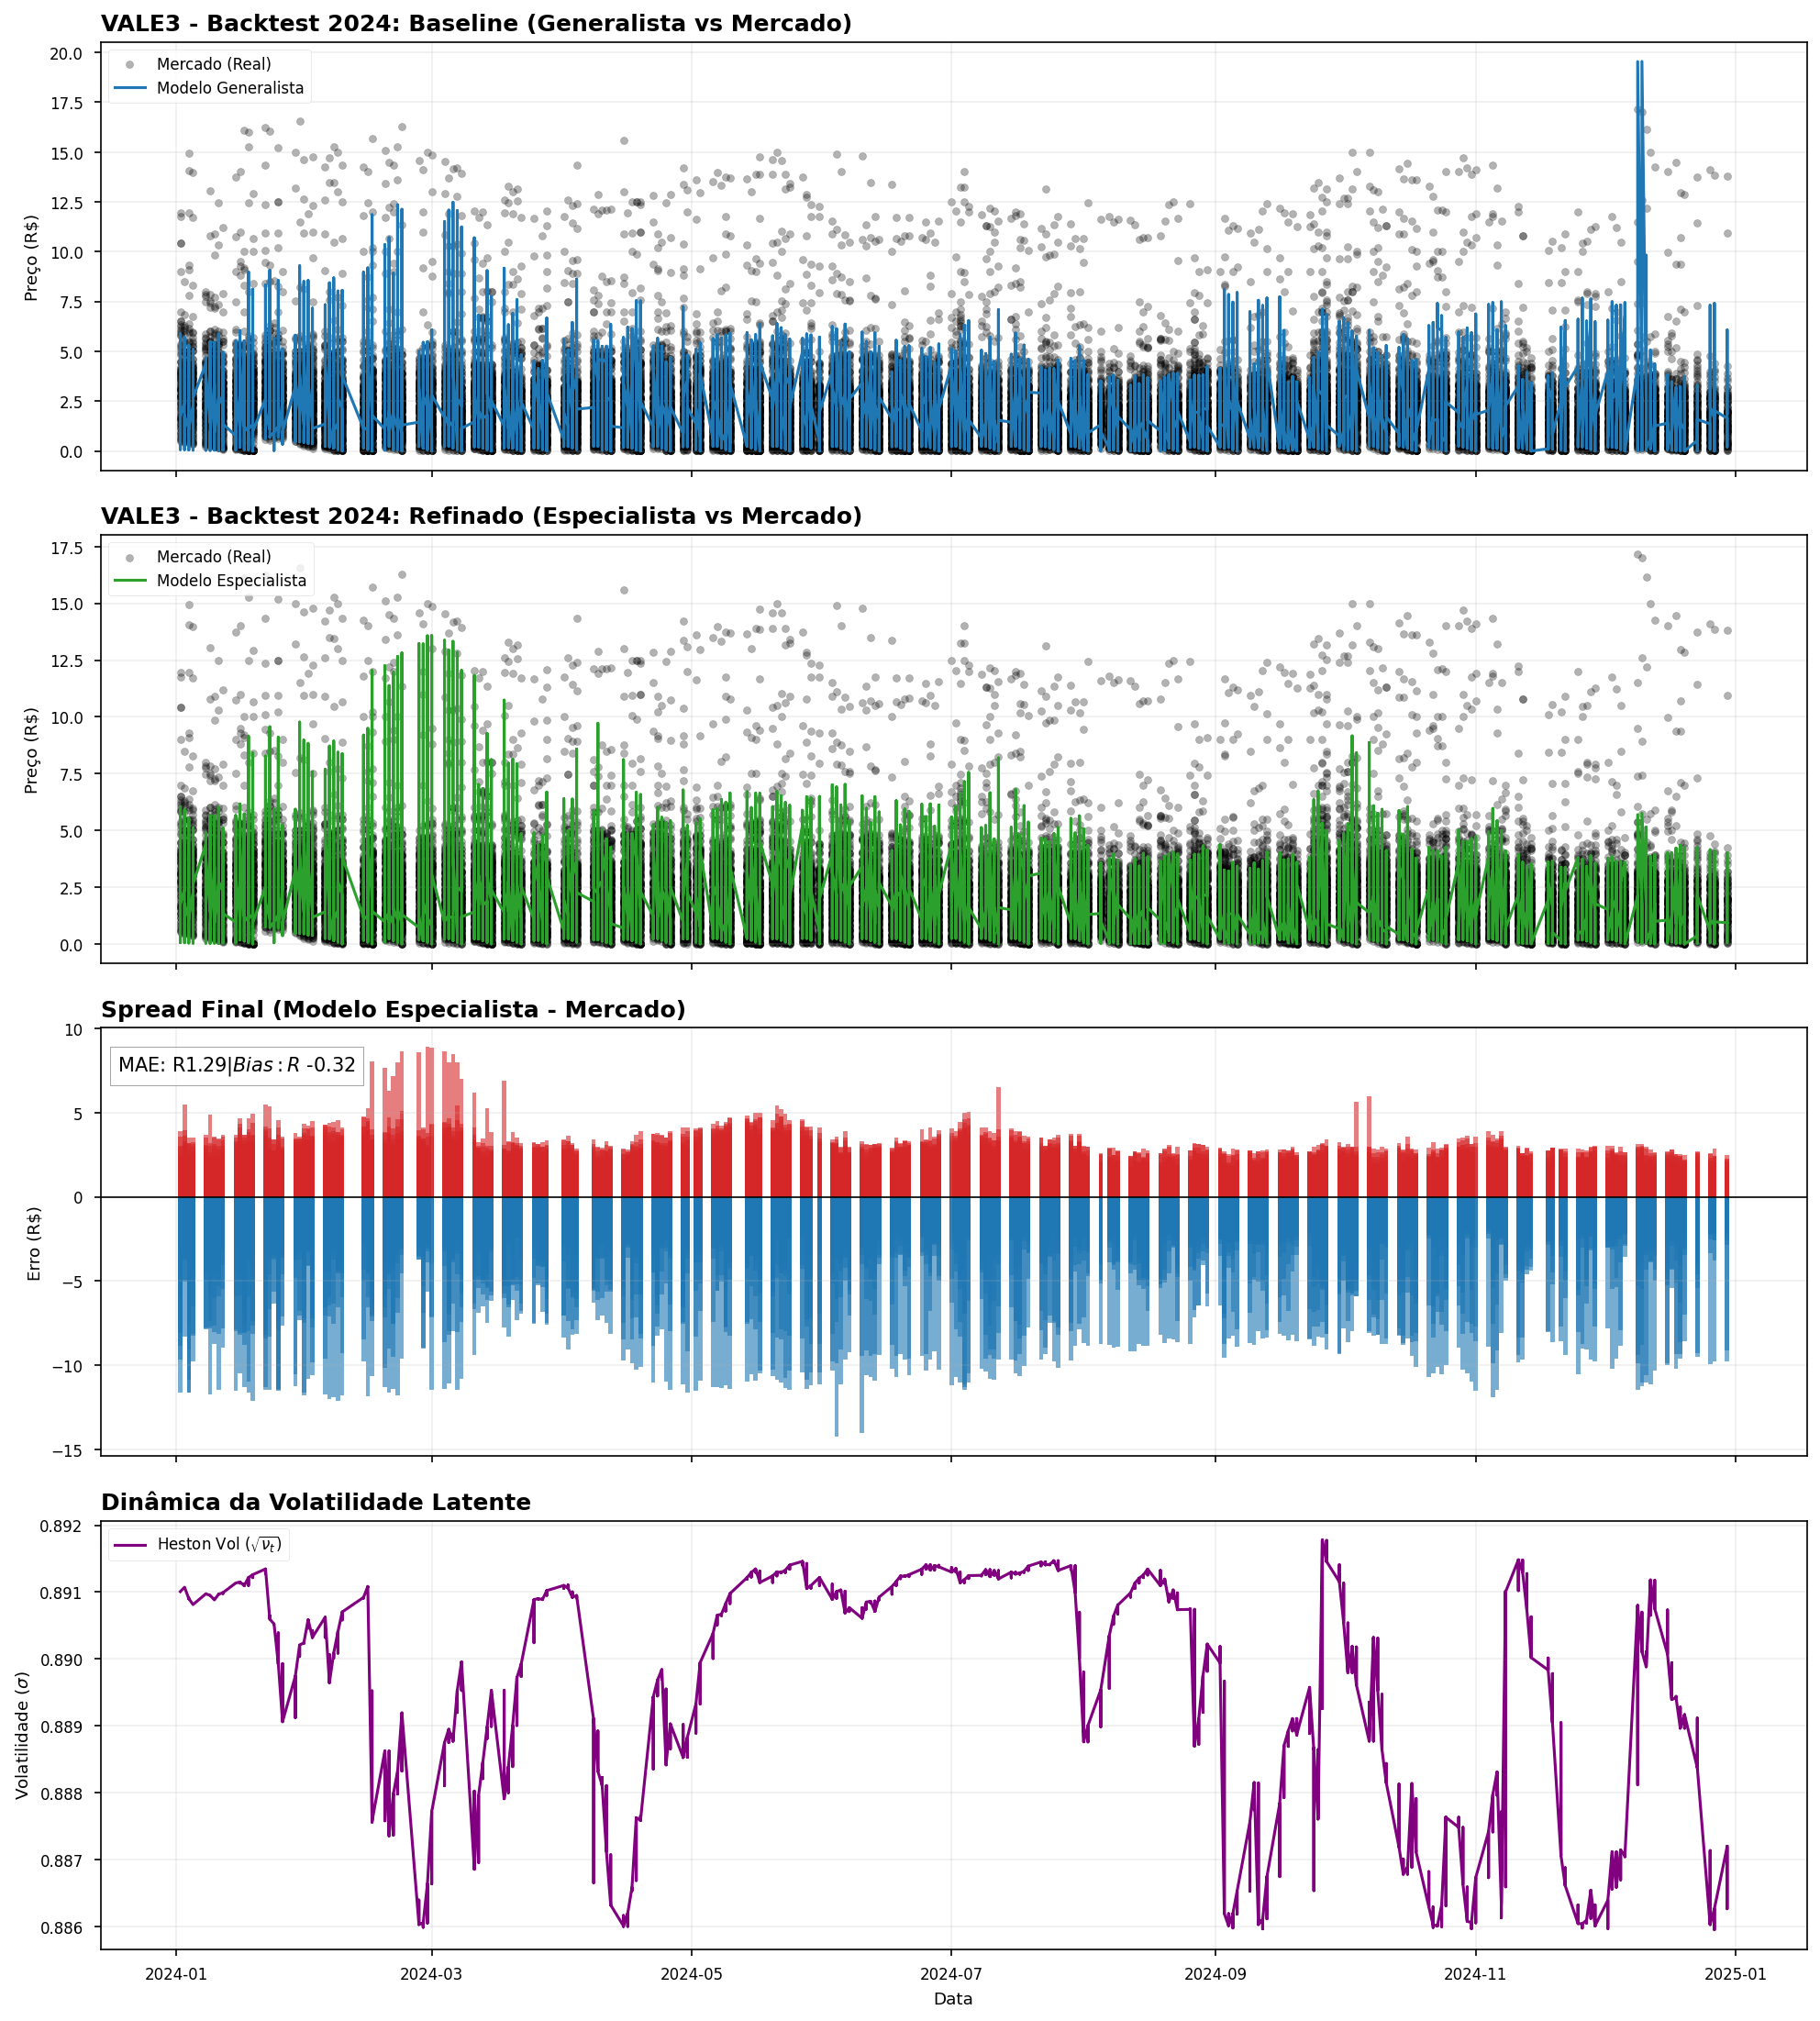

In [8]:
# Execução
plot_split_time_series(df_vale, "VALE3 - Backtest 2024")

ABEV3 - Ambev

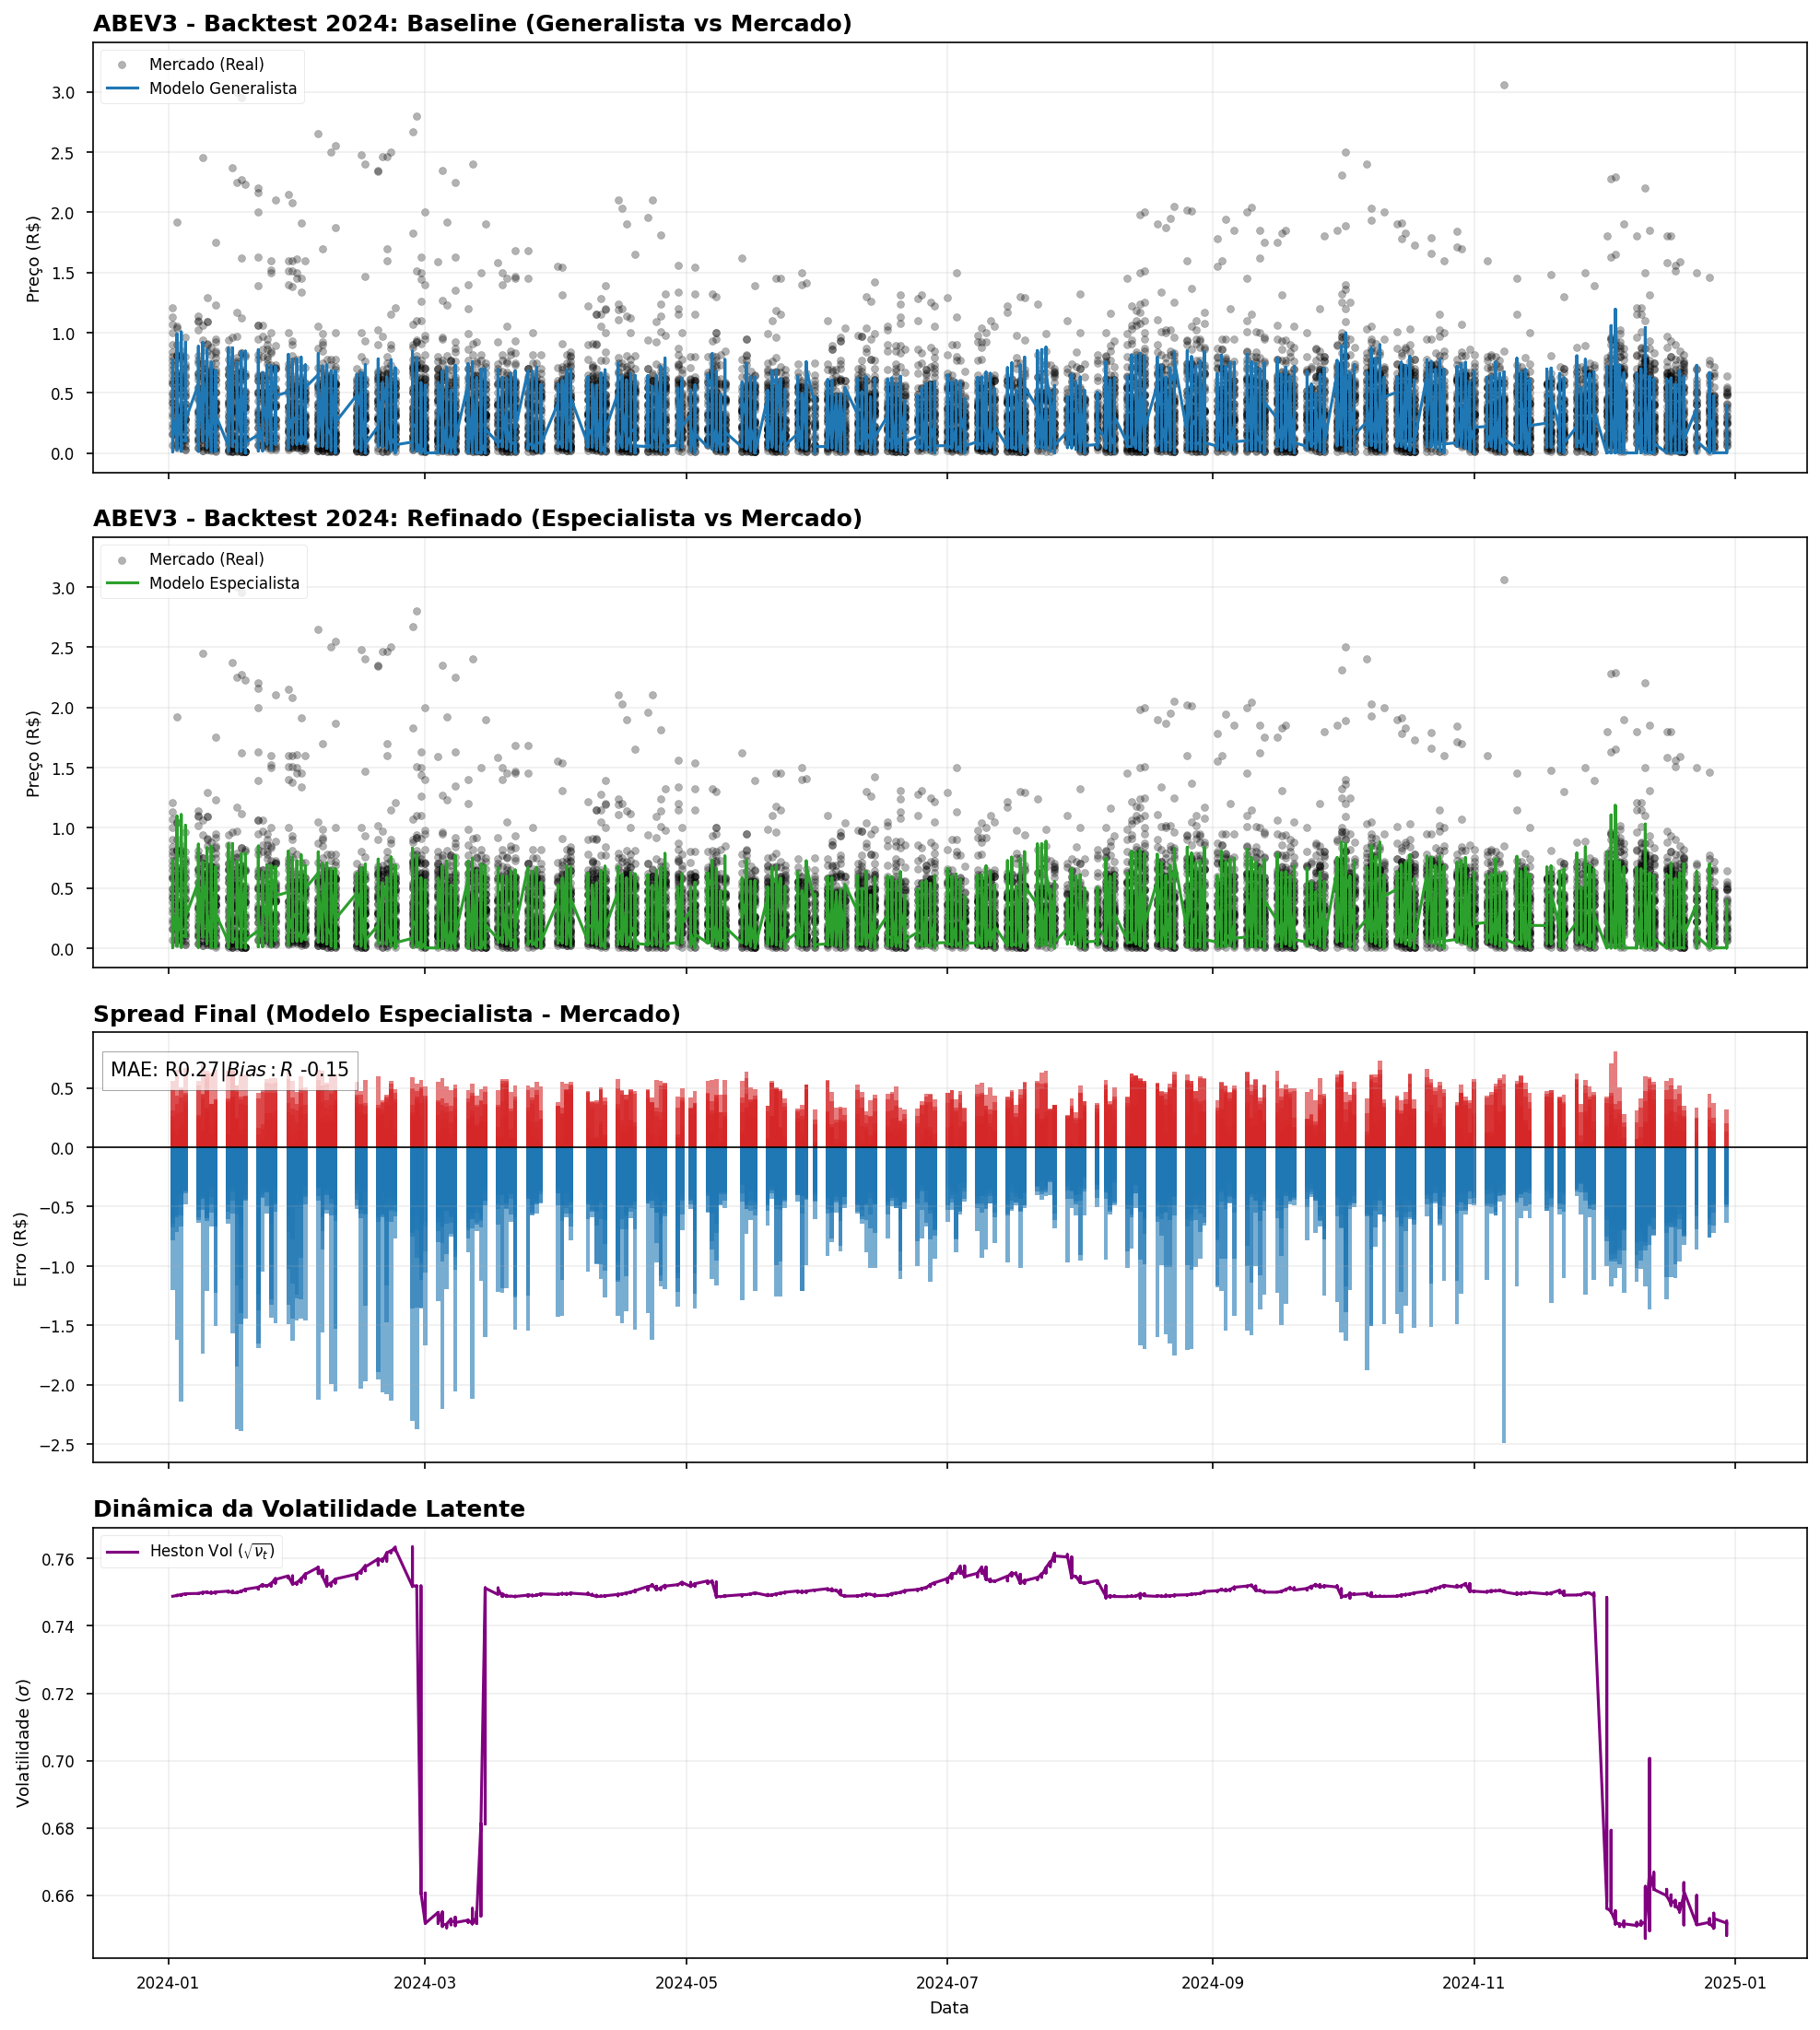

In [9]:
# Execução
plot_split_time_series(df_abev, "ABEV3 - Backtest 2024")

CSN3 - CSN

In [10]:
# Execução
plot_split_time_series(df_csn, "CSN3 - Backtest 2024")

C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_30040\1291716446.py:73: SyntaxWarning: invalid escape sequence '\s'
  ax_vol.set_ylabel('Volatilidade ($\sigma$)')


TypeError: 'NoneType' object is not subscriptable

ITUB4 - Itaú

In [ ]:
# Execução
plot_split_time_series(df_itau, "ITUB4 - Backtest 2024")

### Visualização 2 - Smile de Volatilidade

Como não calculamos Vol Implícita invertendo BS na inferência, plotamos Preço vs Strike para maturidades fixas, que é o proxy direto.


In [ ]:
# Função para plotar Smile/Skew em uma data específica

def plot_pricing_smile(df, data_focada, range_dias=5):
    """
    Plota Preço vs Strike para uma data específica (corte transversal).
    Isso mostra se o modelo capturou o Skew/Smile.
    """
    # Filtra dados perto de uma data
    data_alvo = pd.to_datetime(data_focada)
    mask = (df['time'] >= data_alvo) & (df['time'] <= data_alvo + pd.Timedelta(days=range_dias))
    df_slice = df[mask]
    
    if df_slice.empty:
        print("Sem dados nesta data.")
        return

    # Pega a maturidade mais comum nesse slice para limpar o gráfico
    mat_comum = df_slice['maturity'].mode()[0]
    df_slice = df_slice[np.isclose(df_slice['maturity'], mat_comum, atol=0.01)]
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_slice, x='strike', y='premium_real', label='Mercado', color='black', marker='o')
    sns.lineplot(data=df_slice, x='strike', y='Pred_Spec', label='Modelo Especialista', color='green')
    sns.lineplot(data=df_slice, x='strike', y='Pred_Robusto', label='Modelo Robusto', color='blue', linestyle='--')
    
    plt.title(f"Estrutura a Termo (Smile Proxy) - {data_focada} (Tau={mat_comum:.2f})")
    plt.xlabel("Strike (K)")
    plt.ylabel("Prêmio da Opção")
    plt.grid(True)
    plt.show()

# Exemplo: Pegar um dia volátil de 2024
plot_pricing_smile(df_petr, "2024-03-15")

### Superfície de Erro 3D (Diagnóstico de Bias)

In [11]:
#

def plot_error_surface(df):
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Eixos: Moneyness vs Tempo vs Erro (Spec)
    # Filtrar outliers para visualização
    df_clean = df[(df['Erro_Spec'].abs() < 2.0)]
    
    sc = ax.scatter(
        df_clean['moneyness'], 
        df_clean['maturity'], 
        df_clean['Erro_Spec'],
        c=df_clean['Erro_Spec'], 
        cmap='coolwarm', 
        s=5, 
        alpha=0.6
    )
    
    ax.set_xlabel('Moneyness (S/K)')
    ax.set_ylabel('Tempo (Anos)')
    ax.set_zlabel('Erro de Preço (R$)')
    ax.set_title('Superfície de Erro do Modelo Especialista')
    plt.colorbar(sc, label='Erro Residual')
    plt.show()



PETR4 - Petrobrás

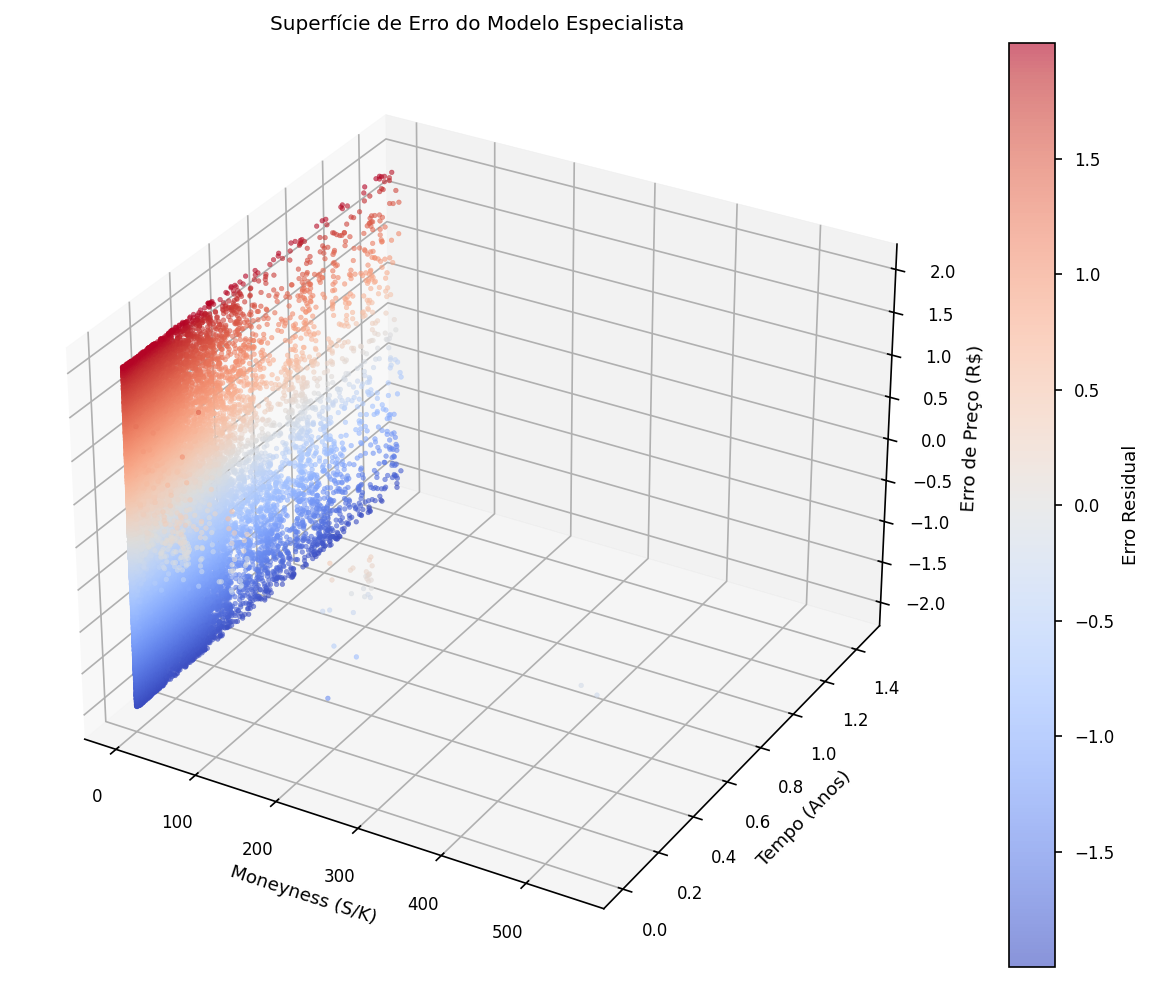

In [12]:
plot_error_surface(df_petr)

VALE3 - Vale

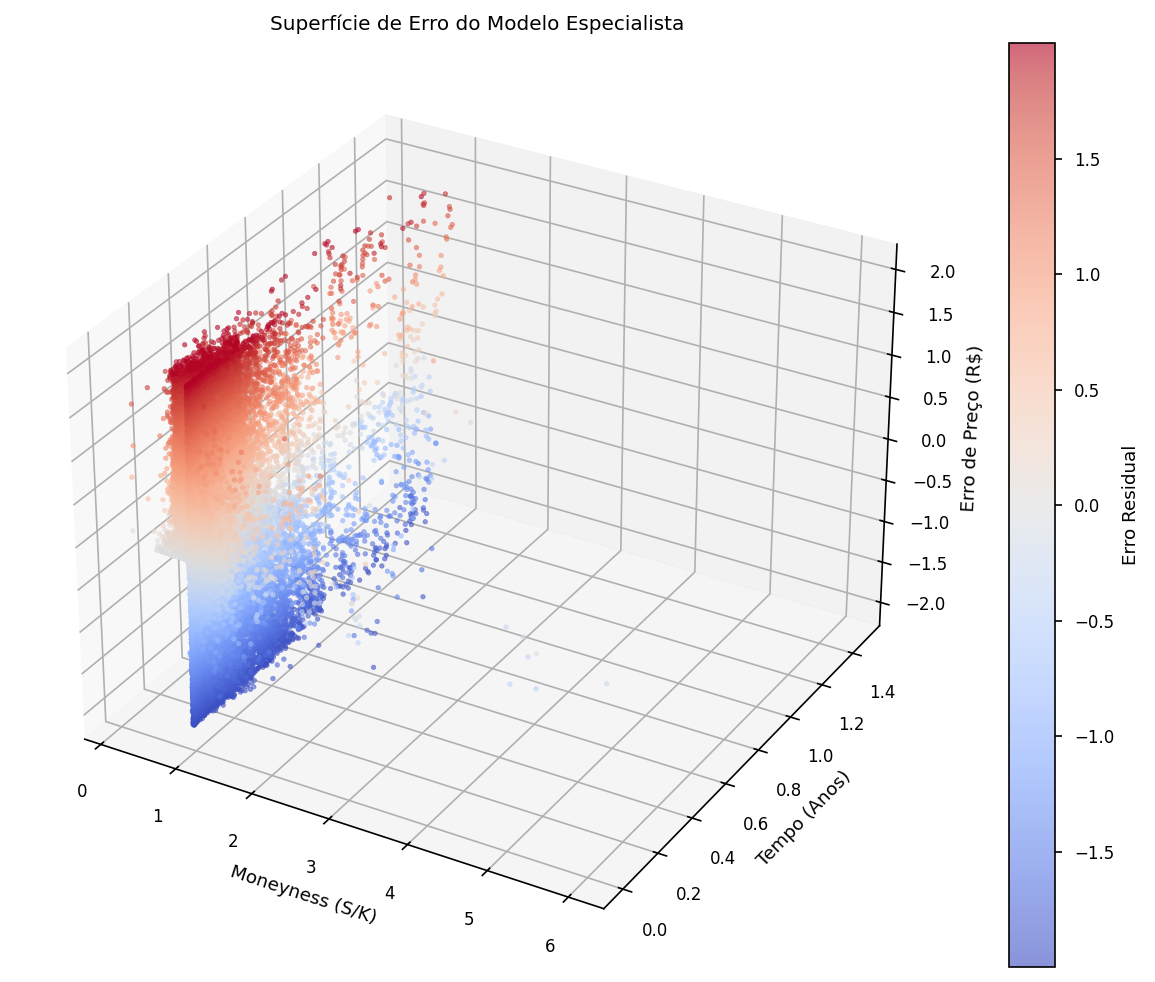

In [13]:
plot_error_surface(df_vale)

ABEV3 - Ambev

In [ ]:
plot_error_surface(df_ambe)

NameError: name 'df_ambev' is not defined

CSN3 - CSN

TypeError: 'NoneType' object is not subscriptable

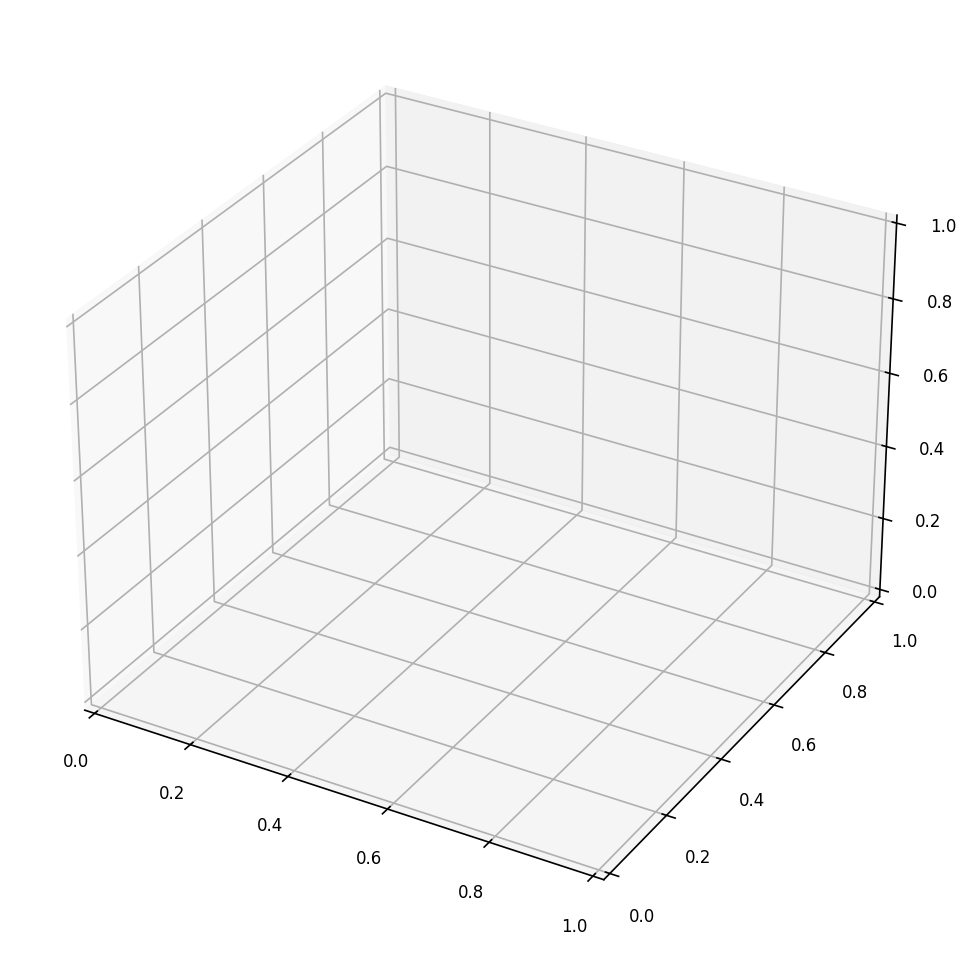

In [15]:
plot_error_surface(df_csn)

ITUB4 - Itaú

In [ ]:
plot_error_surface(df_itau)

### Superfície de Preços

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_superficie_bs(ticker, sigma_fixa=0.30, K_referencia=None):
    """
    Gera uma superfície 3D de Black-Scholes baseada nos limites do modelo.
    """
    # 1. Definir o Strike de referência (usa a média do treino se não informado)
    if K_referencia is None:
        K_ref = data_stats['K_mean']
    else:
        K_ref = K_referencia
        
    # 2. Gerar labels de Spot (de 70% a 130% do Strike) e Tempo (de 1 dia a 1 ano)
    spot_min, spot_max = K_ref * 0.7, K_ref * 1.3
    time_min, time_max = 1/252, 1.0  # Em anos
    
    s_vals = np.linspace(spot_min, spot_max, 50)
    t_vals = np.linspace(time_min, time_max, 50)
    S_grid, T_grid = np.meshgrid(s_vals, t_vals)
    
    # 3. Calcular Preços Black-Scholes
    # Usamos taxa Selic média ou 10% como fallback
    r_ref = data_stats.get('r_mean', 0.10)
    
    Z_bs = black_scholes_price(S_grid, K_ref, T_grid, r_ref, sigma_fixa)
    
    # 4. Plot 3D
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(S_grid, T_grid, Z_bs, cmap='plasma', alpha=0.8, edgecolor='none')
    
    ax.set_title(f'Superfície Black-Scholes: {ticker}\n(K={K_ref:.2f}, σ={sigma_fixa*100:.1f}%, r={r_ref*100:.1f}%)')
    ax.set_xlabel('Preço Spot (S)')
    ax.set_ylabel('Tempo para Vencimento (T em anos)')
    ax.set_zlabel('Prêmio da Opção (R$)')
    
    # Adiciona barra de cores
    fig.colorbar(surf, shrink=0.5, aspect=10)
    
    # Ajusta o ângulo de visão para melhor perspectiva
    ax.view_init(elev=20, azim=-130)
    
    plt.show()



PETR4 - Petrobrás

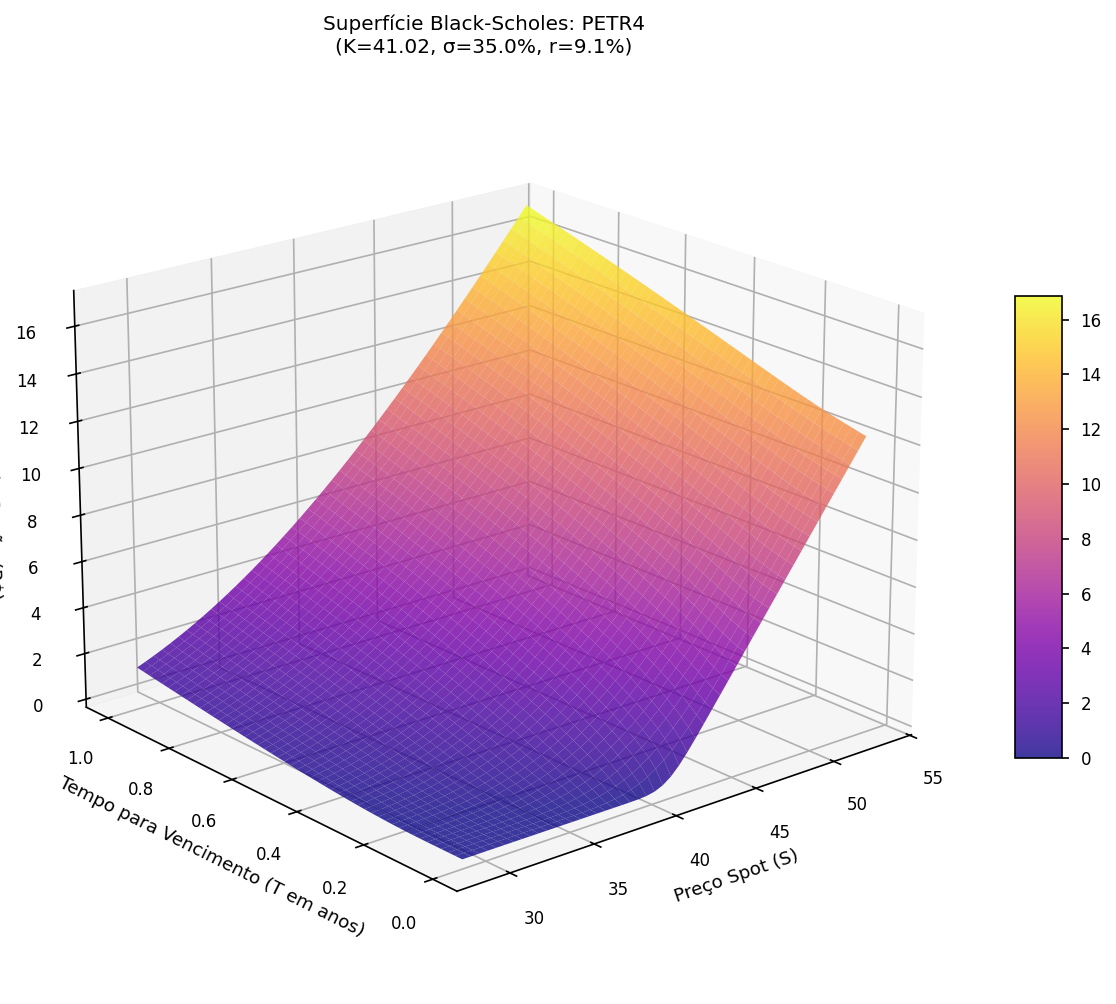

In [17]:
# Exemplo de uso para PETR4
plot_superficie_bs('PETR4', sigma_fixa=0.35)

VALE3 - Vale

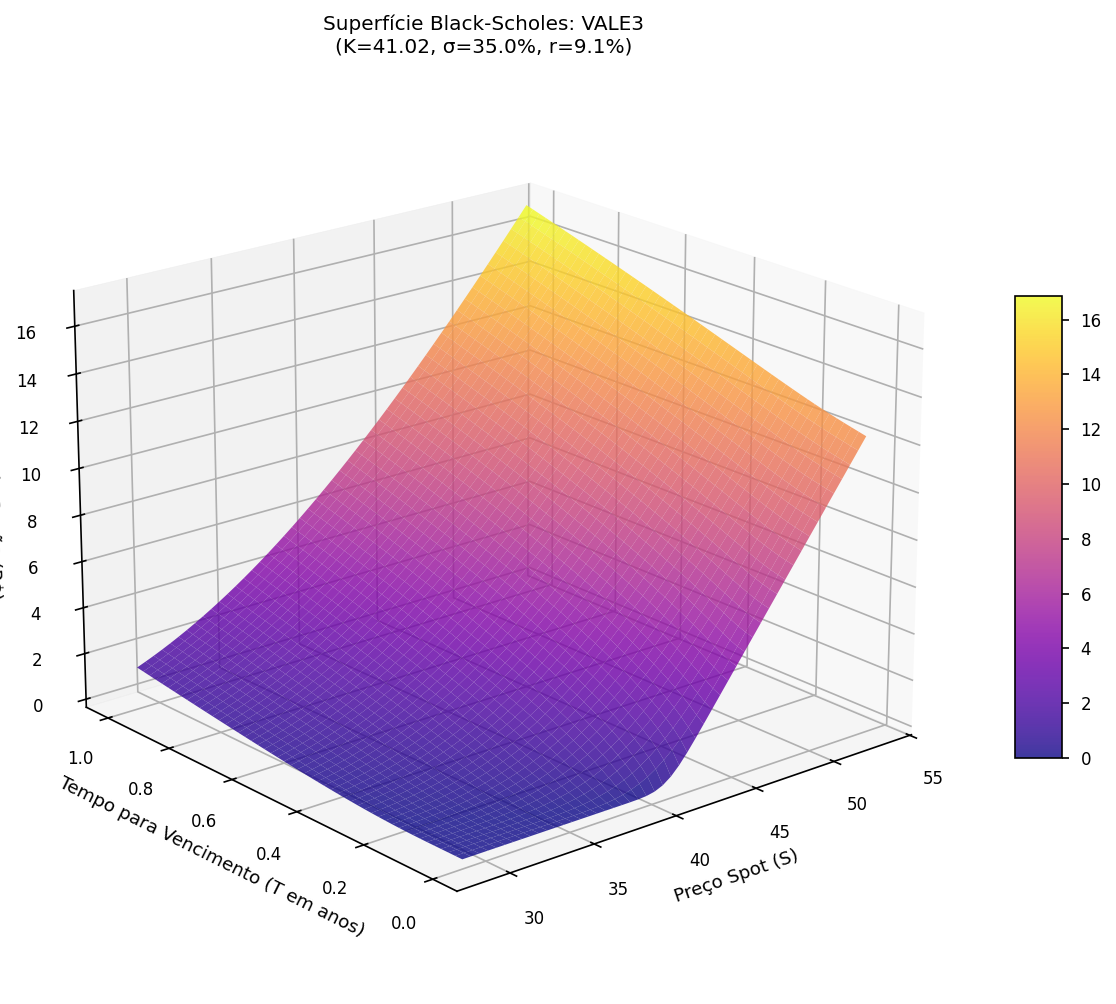

In [18]:

plot_superficie_bs('VALE3', sigma_fixa=0.35)

ABEV3 - Ambev

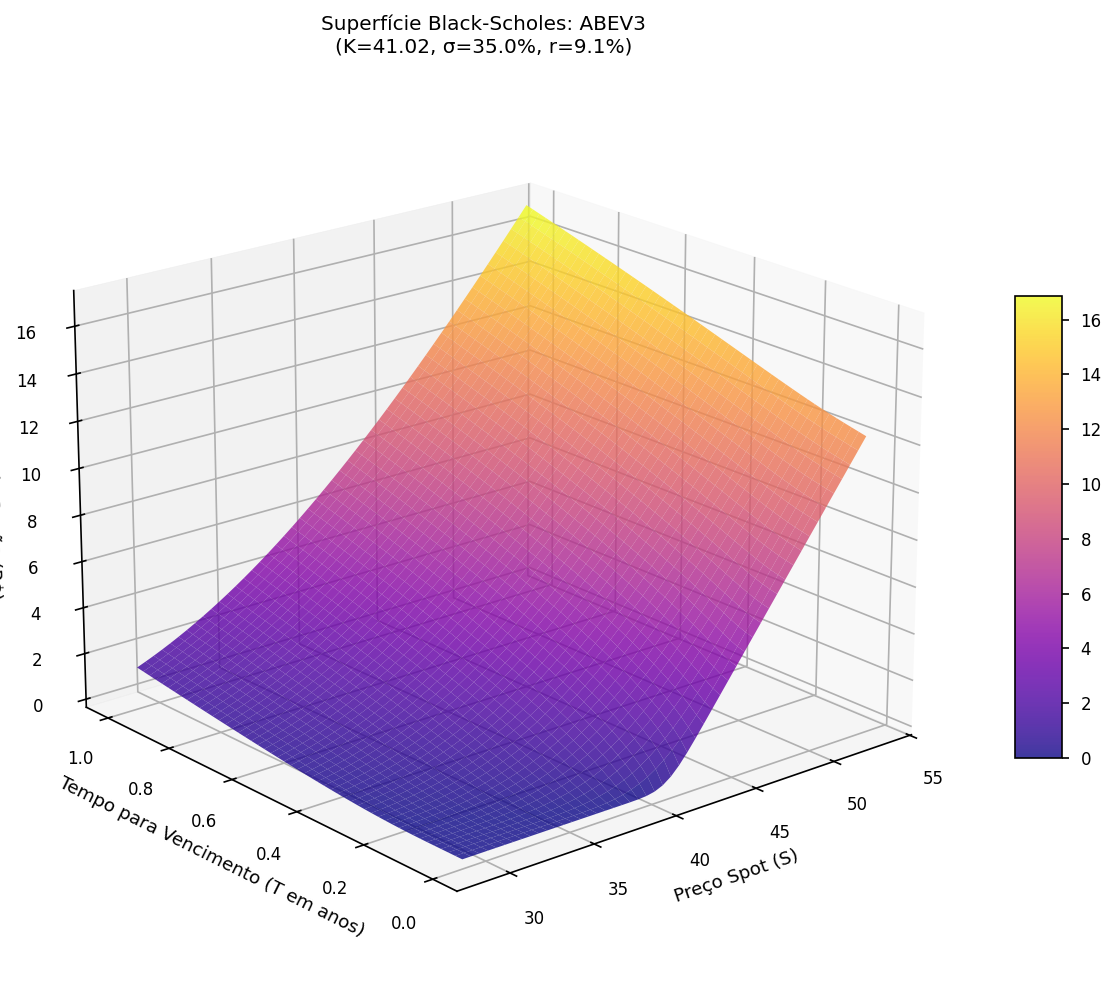

In [19]:

plot_superficie_bs('ABEV3', sigma_fixa=0.35)

CSN3 - CSN

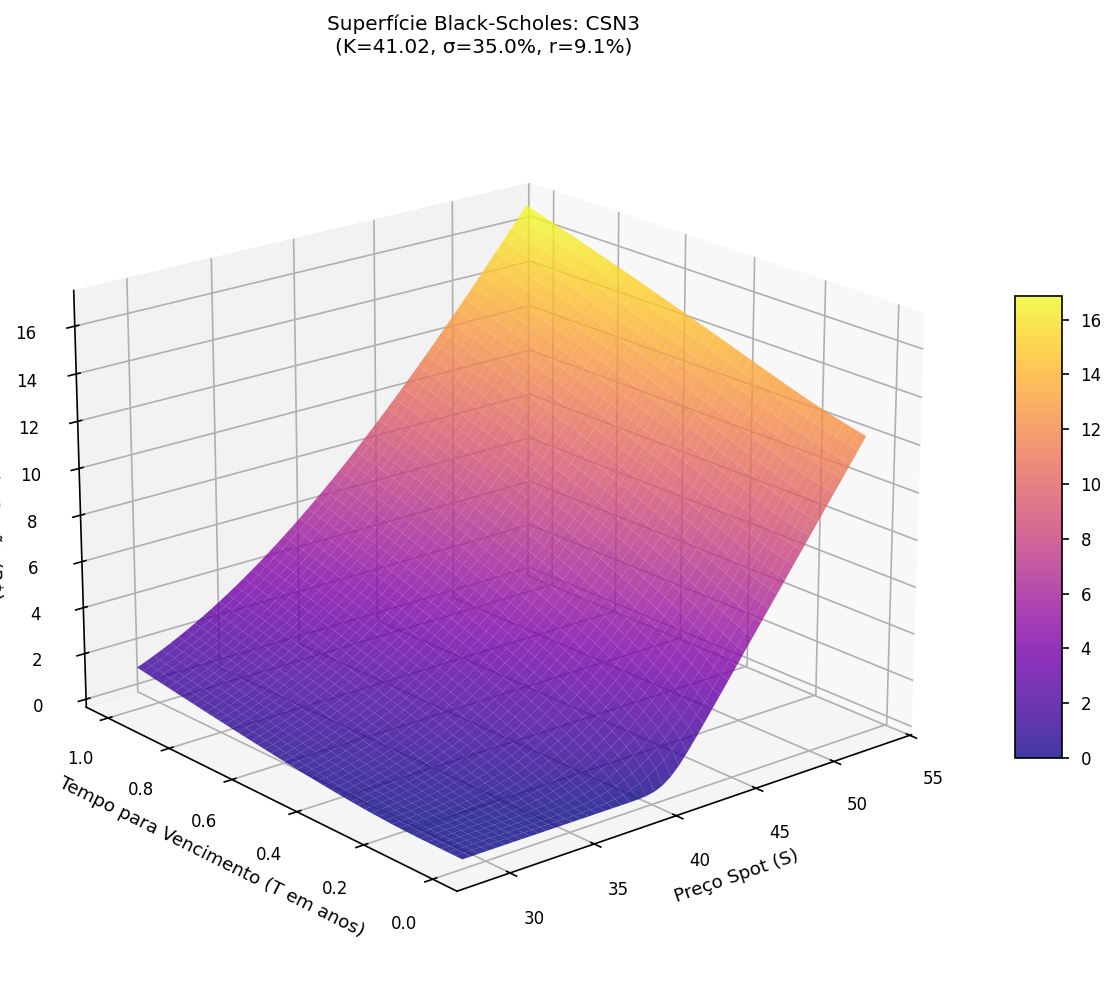

In [20]:

plot_superficie_bs('CSN3', sigma_fixa=0.35)

ITUB4 - Itaú

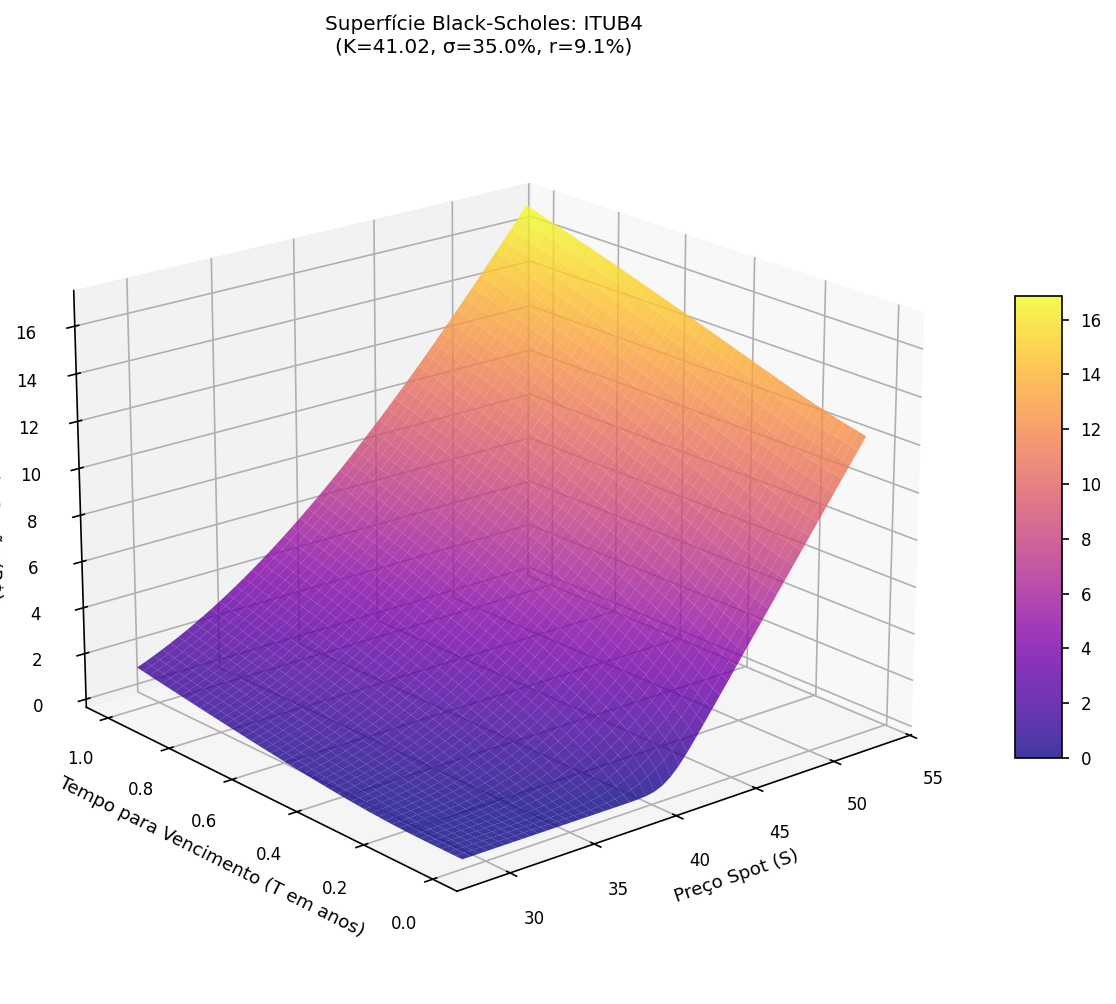

In [21]:

plot_superficie_bs('ITUB4', sigma_fixa=0.35)